フレーム数の確認

In [1]:
import pandas as pd
import os

folder_path = './output_filtered_questions'

# 不足していたラベルの数を数える変数
total_insufficient_count = 0

# 詳細リスト（任意であとから表示用）
insufficient_labels_report = []

# 対象フォルダのCSVファイルを走査
for file_name in os.listdir(folder_path):
    if not file_name.endswith('.csv'):
        continue

    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, low_memory=False)

    # answer1〜10 のみを対象
    df["label"] = df["label"].str.strip()
    filtered_df = df[df["label"].str.match(r'^answer(10|[1-9])$', na=False)]

    # Confidence ≥ 0.90 に絞る
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]

    # ラベルごとのフレーム数をカウント
    frame_counts = filtered_df.groupby("label").size()

    # 30未満のラベルを抽出
    insufficient = frame_counts[frame_counts < 30]

    # 不足件数を合計に加算
    total_insufficient_count += len(insufficient)

    # 詳細保存（任意）
    for label, count in insufficient.items():
        insufficient_labels_report.append((file_name, label, count))

# 結果表示
print(f"\n===== 30フレーム未満のラベル総数 =====")
print(f"{total_insufficient_count} 件")

# 任意：詳細も表示
if insufficient_labels_report:
    print("\n詳細一覧:")
    for file_name, label, count in insufficient_labels_report:
        print(f"{file_name} - {label}: {count} フレーム")


FileNotFoundError: [WinError 3] 指定されたパスが見つかりません。: './output_filtered_questions'

先頭30フレームの最大値を計算(30フレームに満たないものはNaNに変更)

In [8]:
import os
import pandas as pd

# 処理するフォルダのパス
folder_path = r"C:\Users\robotics\proj\Research\output_filtered_questions_copy"

# フォルダ内のすべてのCSVファイルを取得
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
labels = [0,0,1,0,1,
          0,0,0,0,0,
          0,0,0,1,1,
          0,1,0,1,0,
          0,0,0,0,1,
          0,1,1,0,0,
          0,0,0,1,0,
          1,0,0,0,1,
          1,1,1,0,1,
          1,1,0,1,1,
          1,1,1,1,1,
          1,1,1,0,0,
          1,1,1,1,1]
i = 0
# 各ファイルに対して処理を適用
result_list = []  # AUの先頭30フレーム最大値を保存するリスト

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    
    # データの読み込み
    df = pd.read_csv(file_path, low_memory=False)
    
    # `answer1`から`answer10`のみをフィルタリング
    df["label"] = df["label"].str.strip()
    filtered_df = df[df["label"].str.match(r'^answer(10|[1-9])$', na=False)]
    
    # Confidenceが0.90以上の行を抽出
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]
    
    # `Confidence`列と`AU`で始まる列を抽出
    columns_to_extract = ["label", "Confidence"] + [col for col in filtered_df.columns if col.startswith("AU")]
    filtered_df = filtered_df[columns_to_extract]
    
    # 順序を保つためのカスタム順序のカテゴリを定義
    filtered_df["label"] = pd.Categorical(
        filtered_df["label"],
        categories=[f"answer{i}" for i in range(1, 11)],
        ordered=True
    )
    
    # ラベルごとに最初の30フレームを取得
    first_30_frames_per_label = (
        filtered_df.groupby("label")
        .apply(lambda group: group.head(30))
        .reset_index(drop=True)
    )

    # 各labelのフレーム数を確認
    frame_counts = filtered_df.groupby("label").size()

    # 最大値を計算（まずは通常通り）
    max_values_per_label = (
        first_30_frames_per_label.groupby("label").max(numeric_only=True)
    )

    # 30フレーム未満のラベルに対応する行をすべてNaNにする
    #insufficient_labels = frame_counts[frame_counts < 30].index.tolist()
    #for label in insufficient_labels:
        #if label in max_values_per_label.index:
            #max_values_per_label.loc[label] = [float('NaN')] * len(max_values_per_label.columns)

    # NaNを他の列の平均で補完
    for col in max_values_per_label.columns:
        if max_values_per_label[col].isna().any():  # NaNがある場合
            # 各列のNaNを、同じ列の他の行の平均で補完
            max_values_per_label[col] = max_values_per_label[col].fillna(max_values_per_label[col].mean())
    
    # 結果をリストに保存
    result_list.append((file_name, max_values_per_label))

    # Yを追加
    max_values_per_label["Y"] = labels[i]
    i = i + 1
    
# 各ファイルの結果を出力
for file_name, mean_values in result_list:
    print(f"Results for {file_name}:")
    print(mean_values)
    print()


# 合計データ数をカウント
total_data_count = sum(len(mean_values) for _, mean_values in result_list)

# 合計データ数を出力
print(f"合計のデータ数: {total_data_count}")

C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\836340513.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered_df.groupby("label")
C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\836340513.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.head(30))
C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\836340513.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain cu

Results for filtered_ID30.csv:
          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.998552  0.772197  0.470349  0.833798  0.497938  0.281521   1.0   
answer2     0.998392  0.823720  0.504450  0.698435  0.451498  0.273104   1.0   
answer3     0.998105  0.810446  0.634203  0.735056  0.553234  0.224017   1.0   
answer4     0.996902  0.805873  0.572209  0.587676  0.748750  0.229382   1.0   
answer5     0.997551  0.775502  0.627177  0.667268  0.585380  0.243576   1.0   
answer6     0.997832  0.788442  0.728710  0.603687  0.741321  0.221382   1.0   
answer7     0.997573  0.748430  0.691159  0.728610  0.753132  0.290905   1.0   
answer8     0.997223  0.828781  0.607205  0.764085  0.546507  0.219612   1.0   
answer9     0.998192  0.806971  0.617136  0.706027  0.529929  0.314064   1.0   
answer10    0.996892  0.802406  0.600398  0.747122  0.589219  0.245450   1.0   

        

質問1個を1セットとして学習(30フレームに満たない応答は削除)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 削除する列を指定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']

# グリッドサーチ用のパラメータ設定
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # 近傍数の候補
    'weights': ['uniform', 'distance'],  # 重みの種類
    'metric': ['manhattan', 'minkowski']  # 距離計量の種類
}

# 全ファイルごとの精度結果を保存するリスト
accuracy_list = []

# 全てのファイルをテストデータとして順番に使うループ
for i in range(len(result_list)):
    print(f"\n===== テストデータ: ファイル {i+1}/{len(result_list)} =====")
    
    # テストデータとして選ぶファイル
    test_file_name, test_df = result_list[i]
    
    # テストデータを前処理
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    # NaNを含む行を削除
    test_df_cleaned = test_df_cleaned.dropna(axis=0)
    
    y_test = test_df_cleaned['Y']
    X_test = test_df_cleaned.drop(columns=['Y'])
    
    # 学習データをリストに格納
    X_train_list = []
    y_train_list = []
    
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i != j:  # テストデータ以外を学習データにする
            train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            # NaNを含む行を削除
            train_df_cleaned = train_df_cleaned.dropna(axis=0)
            train_df_cleaned.reset_index(inplace=True, drop=True)
            
            X_train = train_df_cleaned.drop(columns=['Y'])  # 'label'も削除
            y_train = train_df_cleaned['Y']
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
    
    # 学習データを結合
    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)
    
    # kNNモデルのグリッドサーチ
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    
    # 最適なモデルを取得
    best_model = grid_search.best_estimator_
    print(f"最適パラメータ: {grid_search.best_params_}")
    
    # テストデータで予測
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # クラス1の確率
    
    # 精度計算
    accuracy = accuracy_score(y_test, y_pred) * 100  # 正答率を%に変換
    
    # 精度をリストに保存
    accuracy_list.append((test_file_name, accuracy))
    
    # 結果表示
    print(f"ファイル名: {test_file_name}")
    print(f"予測率: {accuracy:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 全ファイルごとの精度を表示
print("\n===== 全ファイルごとの予測率 =====")
for file_name, acc in accuracy_list:
    print(f"ファイル名: {file_name}, 予測率: {acc:.2f}%")

# 予測率が50%以上のものをカウント
count_above_40 = sum(1 for _, acc in accuracy_list if acc >= 40)

# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度40%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_40}ファイルが予測率40%以上")

# 正解ラベルが1のもののうち、予測率が40%以上のものをカウント
count_above_40_for_label_1 = sum(
    1 for (_, acc), (test_file_name, test_df) in zip(accuracy_list, result_list)
    if acc >= 40 and (test_df['Y'] == 1).any()
)

# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率40%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_40_for_label_1}ファイルが予測率40%以上")


===== テストデータ: ファイル 1/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID30.csv
予測率: 70.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 1, 0, 1, 0, 0, 0]
クラス1の確率: [0.2, 0.4, 0.4, 0.8, 1.0, 0.0, 0.6, 0.2, 0.4, 0.4]

===== テストデータ: ファイル 2/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID31.csv
予測率: 50.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 1, 1, 0, 0, 0, 1, 1, 1]
クラス1の確率: [0.0, 0.3333333333333333, 0.6666666666666666, 0.6666666666666666, 0.3333333333333333, 0.0, 0.3333333333333333, 0.6666666666666666, 1.0, 0.6666666666666666]

===== テストデータ: ファイル 3/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID32.csv
予測率: 50.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
クラス1の確率: [0.6666666666666666, 0.0, 0.6666666666666666, 0.6666666666666666, 0.3333333333333333, 0.6666666666666666, 0.3333333

## 10個セットで同じ患者で欠損を補完

In [6]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 不要な列を除く
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

# ファイル単位で特徴量を1行に変換
X_all = []
y_all = []

for file_name, df in result_list:
    df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    df_cleaned = df_cleaned.dropna(axis=0)
    
    # 特徴量とラベルに分離
    y = df_cleaned["Y"].iloc[0]  # Yは全行同じはず
    X = df_cleaned.drop(columns=["Y"])
    
    # 1行にflatten
    flat_features = X.values.flatten()
    X_all.append(flat_features)
    y_all.append(y)
    

# DataFrame化
X_all_df = pd.DataFrame(X_all)
y_all_series = pd.Series(y_all)

# Leave-One-Outで1ファイルずつテスト
accuracy_list = []
y_true_all = []
y_pred_all = []

for i in range(len(X_all_df)):
    X_test = X_all_df.iloc[[i]]
    y_test = y_all_series.iloc[[i]]

    X_train = X_all_df.drop(index=i)
    y_train = y_all_series.drop(index=i)

    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_list.append((result_list[i][0], acc))

    # 予測と正解を記録
    y_true_all.append(y_test.values[0])
    y_pred_all.append(y_pred[0])

    print(f"\n===== ファイル: {result_list[i][0]} =====")
    print(f"最適パラメータ: {grid_search.best_params_}")
    print(f"予測率: {acc:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 正解ラベルごとの予測結果をカウント
correct_0 = 0
total_0 = 0
correct_1 = 0
total_1 = 0

for true, pred in zip(y_true_all, y_pred_all):
    if true == 0:
        total_0 += 1
        if pred == 0:
            correct_0 += 1
    elif true == 1:
        total_1 += 1
        if pred == 1:
            correct_1 += 1

print(f"\n===== 正解ラベルごとの予測結果 =====")
print(f"正解ラベルが0のファイル数: {total_0}, 正しく0と予測できた数: {correct_0}")
print(f"正解ラベルが1のファイル数: {total_1}, 正しく1と予測できた数: {correct_1}")

ValueError: 
All the 48 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\robotics\proj\delirium\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\robotics\proj\delirium\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\robotics\proj\delirium\Lib\site-packages\sklearn\neighbors\_classification.py", line 239, in fit
    return self._fit(X, y)
           ~~~~~~~~~^^^^^^
  File "c:\Users\robotics\proj\delirium\Lib\site-packages\sklearn\neighbors\_base.py", line 478, in _fit

## 質問ごとでせん妄かを判定

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

# 質問ごとの全体予測結果を保存
overall_results = []

for q_index in range(10):
    question_label = f"answer{q_index + 1}"
    print(f"\n==== 質問: {question_label} ====")

    question_accuracy_list = []
    question_pred_label_list = []

    for i in range(len(result_list)):
        # テスト対象
        test_file_name, test_df = result_list[i]
        test_row = test_df.loc[[question_label]]

        if test_row.isnull().any().any():
            continue  # データが欠損している場合はスキップ

        # 前処理
        test_row_cleaned = test_row.drop(columns=[col for col in columns_to_drop if col in test_row.columns])
        y_test = test_row_cleaned["Y"]
        X_test = test_row_cleaned.drop(columns=["Y"])

        # 学習データ準備
        X_train_list, y_train_list = [], []

        for j, (train_file_name, train_df) in enumerate(result_list):
            if i == j:
                continue
            if question_label not in train_df.index:
                continue

            train_row = train_df.loc[[question_label]]
            if train_row.isnull().any().any():
                continue

            train_row_cleaned = train_row.drop(columns=[col for col in columns_to_drop if col in train_row.columns])
            X_train = train_row_cleaned.drop(columns=["Y"])
            y_train = train_row_cleaned["Y"]

            X_train_list.append(X_train)
            y_train_list.append(y_train)

        if not X_train_list:
            continue  # 学習データがなければスキップ

        X_train_combined = pd.concat(X_train_list, ignore_index=True)
        y_train_combined = pd.concat(y_train_list, ignore_index=True)

        # 学習
        model = KNeighborsClassifier()
        grid_search = GridSearchCV(model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train_combined, y_train_combined)

        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)[0]
        y_prob = best_model.predict_proba(X_test)[0][1]

        acc = int(y_pred == y_test.iloc[0])
        question_accuracy_list.append(acc)
        question_pred_label_list.append(y_pred)

        print(f"患者: {test_file_name}, 正解: {y_test.iloc[0]}, 予測: {y_pred}, 確率: {y_prob:.2f}")

    # この質問の平均精度
    if question_accuracy_list:
        accuracy_percent = 100 * sum(question_accuracy_list) / len(question_accuracy_list)
        print(f"質問 {question_label} の平均正答率: {accuracy_percent:.2f}%")
        overall_results.append((question_label, accuracy_percent))

# 全体結果
print("\n==== 全体結果 ====")
for q, acc in overall_results:
    print(f"{q}: {acc:.2f}%")



==== 質問: answer1 ====
患者: filtered_ID30.csv, 正解: 0, 予測: 1, 確率: 0.60
患者: filtered_ID31.csv, 正解: 0, 予測: 0, 確率: 0.20
患者: filtered_ID32.csv, 正解: 1, 予測: 1, 確率: 1.00
患者: filtered_ID33.csv, 正解: 0, 予測: 1, 確率: 0.80
患者: filtered_ID34.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID35.csv, 正解: 0, 予測: 1, 確率: 0.80
患者: filtered_ID36.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID37.csv, 正解: 0, 予測: 0, 確率: 0.40
患者: filtered_ID38.csv, 正解: 0, 予測: 0, 確率: 0.40
患者: filtered_ID39.csv, 正解: 0, 予測: 1, 確率: 0.60
患者: filtered_ID40.csv, 正解: 0, 予測: 1, 確率: 0.80
患者: filtered_ID41.csv, 正解: 0, 予測: 1, 確率: 0.60
患者: filtered_ID42.csv, 正解: 0, 予測: 0, 確率: 0.29
患者: filtered_ID43.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID44.csv, 正解: 1, 予測: 0, 確率: 0.40
患者: filtered_ID45.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID46.csv, 正解: 1, 予測: 1, 確率: 0.67
患者: filtered_ID47.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID48.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID49.csv, 正解: 0, 予測: 1, 確率: 0.57
患者: filtered_ID50.csv, 正解: 0, 予測: 1, 確率: 0.67
患者: filtere

患者: filtered_ID76.csv, 正解: 1, 予測: 1, 確率: 0.71
患者: filtered_ID77.csv, 正解: 0, 予測: 1, 確率: 0.71
患者: filtered_ID78.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID79.csv, 正解: 1, 予測: 0, 確率: 0.29
患者: filtered_ID80.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID81.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID82.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID83.csv, 正解: 1, 予測: 1, 確率: 0.71
患者: filtered_ID84.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID85.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID86.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID87.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID88.csv, 正解: 0, 予測: 0, 確率: 0.29
患者: filtered_ID89.csv, 正解: 0, 予測: 0, 確率: 0.29
患者: filtered_ID90.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID91.csv, 正解: 1, 予測: 0, 確率: 0.29
患者: filtered_ID92.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID93.csv, 正解: 1, 予測: 1, 確率: 0.86
患者: filtered_ID94.csv, 正解: 1, 予測: 0, 確率: 0.14
質問 answer3 の平均正答率: 47.69%

==== 質問: answer4 ====
患者: filtered_ID30.csv, 正解: 0, 予測: 1, 確率: 0.67
患者: filtered_ID31.csv, 正解: 0, 予

患者: filtered_ID56.csv, 正解: 1, 予測: 1, 確率: 0.70
患者: filtered_ID57.csv, 正解: 1, 予測: 1, 確率: 0.67
患者: filtered_ID58.csv, 正解: 0, 予測: 0, 確率: 0.34
患者: filtered_ID59.csv, 正解: 0, 予測: 1, 確率: 0.68
患者: filtered_ID60.csv, 正解: 0, 予測: 0, 確率: 0.30
患者: filtered_ID61.csv, 正解: 0, 予測: 0, 確率: 0.00
患者: filtered_ID62.csv, 正解: 0, 予測: 0, 確率: 0.33
患者: filtered_ID63.csv, 正解: 1, 予測: 1, 確率: 0.62
患者: filtered_ID64.csv, 正解: 0, 予測: 0, 確率: 0.33
患者: filtered_ID65.csv, 正解: 1, 予測: 1, 確率: 0.68
患者: filtered_ID66.csv, 正解: 0, 予測: 0, 確率: 0.00
患者: filtered_ID67.csv, 正解: 0, 予測: 0, 確率: 0.33
患者: filtered_ID68.csv, 正解: 0, 予測: 1, 確率: 1.00
患者: filtered_ID69.csv, 正解: 1, 予測: 1, 確率: 0.67
患者: filtered_ID70.csv, 正解: 1, 予測: 1, 確率: 1.00
患者: filtered_ID71.csv, 正解: 1, 予測: 1, 確率: 0.67
患者: filtered_ID72.csv, 正解: 1, 予測: 1, 確率: 0.64
患者: filtered_ID73.csv, 正解: 0, 予測: 1, 確率: 0.67
患者: filtered_ID74.csv, 正解: 1, 予測: 0, 確率: 0.00
患者: filtered_ID75.csv, 正解: 1, 予測: 1, 確率: 0.64
患者: filtered_ID76.csv, 正解: 1, 予測: 1, 確率: 0.66
患者: filtered_ID77.csv, 正解: 0, 予測: 

患者: filtered_ID36.csv, 正解: 0, 予測: 1, 確率: 0.60
患者: filtered_ID37.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID38.csv, 正解: 0, 予測: 1, 確率: 0.57
患者: filtered_ID39.csv, 正解: 0, 予測: 1, 確率: 0.57
患者: filtered_ID40.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID41.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID42.csv, 正解: 0, 予測: 1, 確率: 0.71
患者: filtered_ID43.csv, 正解: 1, 予測: 0, 確率: 0.29
患者: filtered_ID44.csv, 正解: 1, 予測: 0, 確率: 0.29
患者: filtered_ID45.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID46.csv, 正解: 1, 予測: 0, 確率: 0.29
患者: filtered_ID47.csv, 正解: 0, 予測: 1, 確率: 0.57
患者: filtered_ID48.csv, 正解: 1, 予測: 1, 確率: 0.67
患者: filtered_ID49.csv, 正解: 0, 予測: 1, 確率: 0.71
患者: filtered_ID50.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID51.csv, 正解: 0, 予測: 1, 確率: 0.57
患者: filtered_ID52.csv, 正解: 0, 予測: 0, 確率: 0.43
患者: filtered_ID53.csv, 正解: 0, 予測: 1, 確率: 0.71
患者: filtered_ID54.csv, 正解: 1, 予測: 1, 確率: 0.57
患者: filtered_ID55.csv, 正解: 0, 予測: 1, 確率: 1.00
患者: filtered_ID56.csv, 正解: 1, 予測: 0, 確率: 0.43
患者: filtered_ID57.csv, 正解: 1, 予測: 

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

final_patient_predictions = []

for i in range(len(result_list)):
    patient_name, test_df = result_list[i]
    print(f"\n=== 判定中: {patient_name} ===")
    
    per_question_preds = []
    
    for q_index in range(10):
        question_label = f"answer{q_index + 1}"
        
        if question_label not in test_df.index:
            continue
        
        test_row = test_df.loc[[question_label]].drop(columns=[col for col in columns_to_drop if col in test_df.columns])
        if test_row.isnull().any().any():
            continue
        
        y_test = test_row["Y"]
        X_test = test_row.drop(columns=["Y"])
        
        # 学習データの収集
        X_train_list, y_train_list = [], []
        for j, (train_name, train_df) in enumerate(result_list):
            if j == i or question_label not in train_df.index:
                continue
            train_row = train_df.loc[[question_label]].drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            if train_row.isnull().any().any():
                continue
            
            X_train = train_row.drop(columns=["Y"])
            y_train = train_row["Y"]
            X_train_list.append(X_train)
            y_train_list.append(y_train)
        
        if not X_train_list:
            continue
        
        X_train_all = pd.concat(X_train_list, ignore_index=True)
        y_train_all = pd.concat(y_train_list, ignore_index=True)
        
        # モデル学習・予測
        model = KNeighborsClassifier()
        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train_all, y_train_all)
        
        pred = grid.best_estimator_.predict(X_test)[0]
        per_question_preds.append(pred)

        print(f"質問 {question_label}: 予測 = {pred}")
    
    # 全質問の予測から多数決で最終判断（1の割合が0.5以上ならせん妄と判定）
    if per_question_preds:
        final_label = int(np.mean(per_question_preds) >= 0.5)
        print(f"→ {patient_name} の最終判定: {final_label}（せん妄:1 / 非せん妄:0）")
        final_patient_predictions.append((patient_name, final_label))
    else:
        print(f"→ {patient_name}: 質問データ不足により判定不可")
        final_patient_predictions.append((patient_name, None))

# === 全体結果表示 ===
print("\n==== 各患者の最終せん妄判定結果 ====")
for name, label in final_patient_predictions:
    if label is not None:
        print(f"{name}: せん妄={label}")
    else:
        print(f"{name}: 判定不可")

from collections import Counter

# 実際のラベルと予測ラベルのリストを取得
true_labels = []
pred_labels = []

for i, (file_name, df) in enumerate(result_list):
    true_label = df['Y'].iloc[0]  # 患者ごとにラベルは1つのはず
    pred_label = final_patient_predictions[i][1]
    true_labels.append(true_label)
    pred_labels.append(pred_label)

# 実際の0と1の人がどう予測されたかを集計
true_0_pred = Counter()
true_1_pred = Counter()

for true, pred in zip(true_labels, pred_labels):
    if true == 0:
        true_0_pred[pred] += 1
    elif true == 1:
        true_1_pred[pred] += 1

# 表示
print("\n===== ラベルごとの予測結果の内訳 =====")
print(f"実際に0の人: {sum(true_0_pred.values())}人 → 0と予測: {true_0_pred[0]}人, 1と予測: {true_0_pred[1]}人")
print(f"実際に1の人: {sum(true_1_pred.values())}人 → 0と予測: {true_1_pred[0]}人, 1と予測: {true_1_pred[1]}人")



=== 判定中: filtered_ID30.csv ===
質問 answer1: 予測 = 1
質問 answer2: 予測 = 0
質問 answer3: 予測 = 1
質問 answer4: 予測 = 1
質問 answer5: 予測 = 1
質問 answer6: 予測 = 0
質問 answer7: 予測 = 1
質問 answer8: 予測 = 1
質問 answer9: 予測 = 0
質問 answer10: 予測 = 0
→ filtered_ID30.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID31.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 1
質問 answer4: 予測 = 1
質問 answer5: 予測 = 1
質問 answer6: 予測 = 1
質問 answer7: 予測 = 1
質問 answer8: 予測 = 1
質問 answer9: 予測 = 1
質問 answer10: 予測 = 0
→ filtered_ID31.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID32.csv ===
質問 answer1: 予測 = 1
質問 answer2: 予測 = 0
質問 answer3: 予測 = 0
質問 answer4: 予測 = 0
質問 answer5: 予測 = 0
質問 answer6: 予測 = 0
質問 answer7: 予測 = 1
質問 answer8: 予測 = 1
質問 answer9: 予測 = 0
質問 answer10: 予測 = 1
→ filtered_ID32.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID33.csv ===
質問 answer1: 予測 = 1
質問 answer2: 予測 = 0
質問 answer3: 予測 = 0
質問 answer4: 予測 = 0
質問 answer5: 予測 = 0
質問 answer6: 予測 = 0
質問 answer7: 予測 = 0
質問 answer8: 予測 = 1
質問 answer9: 

質問 answer8: 予測 = 1
質問 answer9: 予測 = 1
質問 answer10: 予測 = 1
→ filtered_ID60.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID61.csv ===
質問 answer1: 予測 = 1
質問 answer2: 予測 = 0
質問 answer3: 予測 = 0
質問 answer4: 予測 = 1
質問 answer5: 予測 = 1
質問 answer6: 予測 = 0
質問 answer7: 予測 = 0
質問 answer8: 予測 = 0
質問 answer9: 予測 = 0
質問 answer10: 予測 = 1
→ filtered_ID61.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID62.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 1
質問 answer4: 予測 = 0
質問 answer5: 予測 = 0
質問 answer6: 予測 = 0
質問 answer7: 予測 = 1
質問 answer8: 予測 = 0
質問 answer9: 予測 = 0
質問 answer10: 予測 = 0
→ filtered_ID62.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID63.csv ===
質問 answer1: 予測 = 1
質問 answer2: 予測 = 0
質問 answer3: 予測 = 0
質問 answer4: 予測 = 1
質問 answer5: 予測 = 0
質問 answer6: 予測 = 1
質問 answer7: 予測 = 0
質問 answer8: 予測 = 1
質問 answer9: 予測 = 1
質問 answer10: 予測 = 1
→ filtered_ID63.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID64.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 1
質問 a

質問 answer2: 予測 = 0
質問 answer3: 予測 = 0
質問 answer4: 予測 = 1
質問 answer5: 予測 = 0
質問 answer6: 予測 = 1
質問 answer7: 予測 = 1
質問 answer8: 予測 = 1
質問 answer9: 予測 = 0
質問 answer10: 予測 = 0
→ filtered_ID91.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID92.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 1
質問 answer4: 予測 = 1
質問 answer5: 予測 = 1
質問 answer6: 予測 = 0
質問 answer7: 予測 = 0
質問 answer8: 予測 = 1
質問 answer9: 予測 = 1
質問 answer10: 予測 = 1
→ filtered_ID92.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID93.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 1
質問 answer4: 予測 = 0
質問 answer5: 予測 = 1
質問 answer6: 予測 = 0
質問 answer7: 予測 = 0
質問 answer8: 予測 = 0
質問 answer9: 予測 = 0
質問 answer10: 予測 = 1
→ filtered_ID93.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID94.csv ===
質問 answer1: 予測 = 0
質問 answer2: 予測 = 1
質問 answer3: 予測 = 0
質問 answer4: 予測 = 0
質問 answer5: 予測 = 0
質問 answer6: 予測 = 1
質問 answer7: 予測 = 0
質問 answer8: 予測 = 0
質問 answer9: 予測 = 0
質問 answer10: 予測 = 0
→ filtered_ID94.csv の最終判

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

final_patient_predictions = []
true_labels = []
pred_labels = []

# 質問ごとの正解・合計数を記録
question_correct = defaultdict(int)
question_total = defaultdict(int)

for i in range(len(result_list)):
    patient_name, test_df = result_list[i]
    print(f"\n=== 判定中: {patient_name} ===")
    
    per_question_preds = []
    
    for q_index in range(10):
        question_label = f"answer{q_index + 1}"
        
        if question_label not in test_df.index:
            continue
        
        test_row = test_df.loc[[question_label]].drop(columns=[col for col in columns_to_drop if col in test_df.columns])
        if test_row.isnull().any().any():
            continue
        
        y_test = test_row["Y"]
        X_test = test_row.drop(columns=["Y"])
        
        # 学習データ収集
        X_train_list, y_train_list = [], []
        for j, (train_name, train_df) in enumerate(result_list):
            if j == i or question_label not in train_df.index:
                continue
            train_row = train_df.loc[[question_label]].drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            if train_row.isnull().any().any():
                continue
            
            X_train = train_row.drop(columns=["Y"])
            y_train = train_row["Y"]
            X_train_list.append(X_train)
            y_train_list.append(y_train)
        
        if not X_train_list:
            continue
        
        X_train_all = pd.concat(X_train_list, ignore_index=True)
        y_train_all = pd.concat(y_train_list, ignore_index=True)
        
        model = KNeighborsClassifier()
        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train_all, y_train_all)
        
        pred = grid.best_estimator_.predict(X_test)[0]
        per_question_preds.append(pred)

        # 正答率記録
        if y_test.values[0] == pred:
            question_correct[question_label] += 1
        question_total[question_label] += 1

        print(f"質問 {question_label}: 予測 = {pred}, 正解 = {y_test.values[0]}")
    
    # 多数決で最終判定
    if per_question_preds:
        final_label = int(np.mean(per_question_preds) >= 0.4)
        print(f"→ {patient_name} の最終判定: {final_label}（せん妄:1 / 非せん妄:0）")
        final_patient_predictions.append((patient_name, final_label))
        true_labels.append(test_df['Y'].iloc[0])
        pred_labels.append(final_label)
    else:
        print(f"→ {patient_name}: 質問データ不足により判定不可")
        final_patient_predictions.append((patient_name, None))
        true_labels.append(test_df['Y'].iloc[0])
        pred_labels.append(None)

# ===== 最終結果表示 =====
print("\n==== 各患者の最終せん妄判定結果 ====")
for name, label in final_patient_predictions:
    if label is not None:
        print(f"{name}: せん妄={label}")
    else:
        print(f"{name}: 判定不可")

# ===== 質問ごとの正答率 =====
print("\n==== 質問ごとの正答率 ====")
for q in sorted(question_total.keys()):
    correct = question_correct[q]
    total = question_total[q]
    accuracy = 100 * correct / total if total > 0 else 0
    print(f"{q}: {correct}/{total} 正解 ({accuracy:.2f}%)")

# ===== 真のラベル vs 予測の内訳 =====
true_0_pred = Counter()
true_1_pred = Counter()

for true, pred in zip(true_labels, pred_labels):
    if pred is None:
        continue
    if true == 0:
        true_0_pred[pred] += 1
    elif true == 1:
        true_1_pred[pred] += 1

print("\n===== ラベルごとの予測結果の内訳 =====")
print(f"実際に0の人: {sum(true_0_pred.values())}人 → 0と予測: {true_0_pred[0]}人, 1と予測: {true_0_pred[1]}人")
print(f"実際に1の人: {sum(true_1_pred.values())}人 → 0と予測: {true_1_pred[0]}人, 1と予測: {true_1_pred[1]}人")



=== 判定中: filtered_ID30.csv ===
質問 answer1: 予測 = 1, 正解 = 0
質問 answer2: 予測 = 0, 正解 = 0
質問 answer3: 予測 = 1, 正解 = 0
質問 answer4: 予測 = 1, 正解 = 0
質問 answer5: 予測 = 1, 正解 = 0
質問 answer6: 予測 = 0, 正解 = 0
質問 answer7: 予測 = 1, 正解 = 0
質問 answer8: 予測 = 1, 正解 = 0
質問 answer9: 予測 = 0, 正解 = 0
質問 answer10: 予測 = 0, 正解 = 0
→ filtered_ID30.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID31.csv ===
質問 answer1: 予測 = 0, 正解 = 0
質問 answer2: 予測 = 1, 正解 = 0
質問 answer3: 予測 = 1, 正解 = 0
質問 answer4: 予測 = 1, 正解 = 0
質問 answer5: 予測 = 1, 正解 = 0
質問 answer6: 予測 = 1, 正解 = 0
質問 answer7: 予測 = 1, 正解 = 0
質問 answer8: 予測 = 1, 正解 = 0
質問 answer9: 予測 = 1, 正解 = 0
質問 answer10: 予測 = 0, 正解 = 0
→ filtered_ID31.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID32.csv ===
質問 answer1: 予測 = 1, 正解 = 1
質問 answer2: 予測 = 0, 正解 = 1
質問 answer3: 予測 = 0, 正解 = 1
質問 answer4: 予測 = 0, 正解 = 1
質問 answer5: 予測 = 0, 正解 = 1
質問 answer6: 予測 = 0, 正解 = 1
質問 answer7: 予測 = 1, 正解 = 1
質問 answer8: 予測 = 1, 正解 = 1
質問 answer9: 予測 = 0, 正解 = 1
質問 answer10: 予測 = 1, 正解 = 1
→

質問 answer7: 予測 = 0, 正解 = 0
質問 answer8: 予測 = 1, 正解 = 0
質問 answer9: 予測 = 1, 正解 = 0
質問 answer10: 予測 = 1, 正解 = 0
→ filtered_ID53.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID54.csv ===
質問 answer1: 予測 = 1, 正解 = 1
質問 answer2: 予測 = 0, 正解 = 1
質問 answer3: 予測 = 1, 正解 = 1
質問 answer4: 予測 = 1, 正解 = 1
質問 answer5: 予測 = 1, 正解 = 1
質問 answer6: 予測 = 1, 正解 = 1
質問 answer7: 予測 = 1, 正解 = 1
質問 answer8: 予測 = 1, 正解 = 1
質問 answer9: 予測 = 1, 正解 = 1
質問 answer10: 予測 = 0, 正解 = 1
→ filtered_ID54.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID55.csv ===
質問 answer1: 予測 = 1, 正解 = 0
質問 answer2: 予測 = 0, 正解 = 0
質問 answer3: 予測 = 1, 正解 = 0
質問 answer4: 予測 = 1, 正解 = 0
質問 answer5: 予測 = 1, 正解 = 0
質問 answer6: 予測 = 1, 正解 = 0
質問 answer7: 予測 = 0, 正解 = 0
質問 answer8: 予測 = 1, 正解 = 0
質問 answer9: 予測 = 1, 正解 = 0
質問 answer10: 予測 = 1, 正解 = 0
→ filtered_ID55.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID56.csv ===
質問 answer1: 予測 = 0, 正解 = 1
質問 answer2: 予測 = 1, 正解 = 1
質問 answer3: 予測 = 0, 正解 = 1
質問 answer4: 予測 = 0, 正解 = 1
質問 answer5

質問 answer2: 予測 = 1, 正解 = 0
質問 answer3: 予測 = 1, 正解 = 0
質問 answer4: 予測 = 0, 正解 = 0
質問 answer5: 予測 = 0, 正解 = 0
質問 answer6: 予測 = 1, 正解 = 0
質問 answer7: 予測 = 1, 正解 = 0
質問 answer8: 予測 = 1, 正解 = 0
質問 answer9: 予測 = 1, 正解 = 0
質問 answer10: 予測 = 1, 正解 = 0
→ filtered_ID77.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID78.csv ===
質問 answer1: 予測 = 1, 正解 = 1
質問 answer2: 予測 = 0, 正解 = 1
質問 answer3: 予測 = 0, 正解 = 1
質問 answer4: 予測 = 0, 正解 = 1
質問 answer5: 予測 = 1, 正解 = 1
質問 answer6: 予測 = 1, 正解 = 1
質問 answer7: 予測 = 1, 正解 = 1
質問 answer8: 予測 = 1, 正解 = 1
質問 answer9: 予測 = 0, 正解 = 1
質問 answer10: 予測 = 0, 正解 = 1
→ filtered_ID78.csv の最終判定: 1（せん妄:1 / 非せん妄:0）

=== 判定中: filtered_ID79.csv ===
質問 answer1: 予測 = 0, 正解 = 1
質問 answer2: 予測 = 0, 正解 = 1
質問 answer3: 予測 = 0, 正解 = 1
質問 answer4: 予測 = 0, 正解 = 1
質問 answer5: 予測 = 0, 正解 = 1
質問 answer6: 予測 = 0, 正解 = 1
質問 answer7: 予測 = 0, 正解 = 1
質問 answer8: 予測 = 0, 正解 = 1
質問 answer9: 予測 = 1, 正解 = 1
質問 answer10: 予測 = 0, 正解 = 1
→ filtered_ID79.csv の最終判定: 0（せん妄:1 / 非せん妄:0）

=== 判定中: filte

In [11]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import defaultdict
import numpy as np

# パラメータ設定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

# 質問ごとの正答カウント用
question_correct = defaultdict(int)
question_total = defaultdict(int)

# 患者ごとの真のラベルと予測結果を記録
true_labels = []
predicted_labels = []

# 各患者を1人ずつテストデータに
for i in range(len(result_list)):
    test_file_name, test_df = result_list[i]
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    test_df_cleaned = test_df_cleaned.dropna(axis=0)

    y_test_all = test_df_cleaned['Y'].values
    X_test_all = test_df_cleaned.drop(columns=['Y'])

    # 学習データ作成
    X_train_list, y_train_list = [], []
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i == j:
            continue
        train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
        train_df_cleaned = train_df_cleaned.dropna(axis=0)

        X_train = train_df_cleaned.drop(columns=['Y'])
        y_train = train_df_cleaned['Y']

        X_train_list.append(X_train)
        y_train_list.append(y_train)

    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)

    # グリッドサーチでkNNモデルを学習
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    best_model = grid_search.best_estimator_

    # 質問ごとの予測
    y_pred_all = best_model.predict(X_test_all)

    # 質問ごとの正答率計算
    for j, label in enumerate(X_test_all.index):  # answer1〜answer10
        question_total[label] += 1
        if y_test_all[j] == y_pred_all[j]:
            question_correct[label] += 1

    # 各質問の予測結果から多数決で患者の最終予測を決定
    votes = np.sum(y_pred_all)  # y=1の数
    final_prediction = 1 if votes >= 5 else 0  # 5問以上1ならせん妄と判定
    final_true_label = y_test_all[0]  # 全て同じはず

    predicted_labels.append(final_prediction)
    true_labels.append(final_true_label)

# ===== 全体評価 =====
print("\n===== 質問ごとの正答率 =====")
for q in sorted(question_total.keys()):
    correct = question_correct[q]
    total = question_total[q]
    acc = (correct / total) * 100 if total > 0 else 0
    print(f"{q}: {correct}/{total} ({acc:.2f}%)")

# ===== 感度・特異度など =====
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if tp + fn > 0 else 0  # Recall / True Positive Rate
specificity = tn / (tn + fp) if tn + fp > 0 else 0  # True Negative Rate
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("\n===== 最終患者単位の判定精度 =====")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")

print("\n===== 真のラベル vs 予測数 =====")
print(f"真のラベル 0: {true_labels.count(0)}人 → 予測0: {sum(p == 0 and t == 0 for p, t in zip(predicted_labels, true_labels))}人, 予測1: {sum(p == 1 and t == 0 for p, t in zip(predicted_labels, true_labels))}人")
print(f"真のラベル 1: {true_labels.count(1)}人 → 予測1: {sum(p == 1 and t == 1 for p, t in zip(predicted_labels, true_labels))}人, 予測0: {sum(p == 0 and t == 1 for p, t in zip(predicted_labels, true_labels))}人")



===== 質問ごとの正答率 =====
answer1: 30/65 (46.15%)
answer10: 32/65 (49.23%)
answer2: 33/65 (50.77%)
answer3: 31/65 (47.69%)
answer4: 29/65 (44.62%)
answer5: 32/65 (49.23%)
answer6: 37/65 (56.92%)
answer7: 35/65 (53.85%)
answer8: 30/65 (46.15%)
answer9: 37/65 (56.92%)

===== 最終患者単位の判定精度 =====
Accuracy: 60.00%
Sensitivity (Recall): 78.79%
Specificity: 40.62%

===== 真のラベル vs 予測数 =====
真のラベル 0: 32人 → 予測0: 13人, 予測1: 19人
真のラベル 1: 33人 → 予測1: 26人, 予測0: 7人


## 10個セットで他の患者の同じ質問で欠損を補完
（同じデータの患者が二つで以上あることになる）

In [30]:
import os
import pandas as pd

# 処理するフォルダのパス
folder_path = './output_filtered_questions'

# フォルダ内のすべてのCSVファイルを取得
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
labels = labels = [0,0,1,0,1,
          0,0,0,0,0,
          0,0,0,1,1,
          0,1,0,1,0,
          0,0,0,0,1,
          0,1,1,0,0,
          0,0,0,1,0,
          1,0,0,0,1,
          1,1,1,0,1,
          1,1,0,1,1,
          1,1,1,1,1,
          1,1,1,0,0,
          1,1,1,1,1]

# すべてのファイルのデータを保存するリスト
all_data_by_label = {f"answer{i}": [] for i in range(1, 11)}

# 個別ファイル処理前にデータ収集
for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, low_memory=False)
    df["label"] = df["label"].str.strip()
    filtered_df = df[df["label"].str.match(r'^answer(10|[1-9])$', na=False)]
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]
    columns_to_extract = ["label", "Confidence"] + [col for col in filtered_df.columns if col.startswith("AU")]
    filtered_df = filtered_df[columns_to_extract]
    filtered_df["label"] = pd.Categorical(filtered_df["label"], categories=[f"answer{i}" for i in range(1, 11)], ordered=True)
    first_30 = filtered_df.groupby("label").apply(lambda group: group.head(30)).reset_index(drop=True)
    max_per_label = first_30.groupby("label").max(numeric_only=True)

    for label in max_per_label.index:
        all_data_by_label[label].append(max_per_label.loc[label])

# ラベルごとのグローバル平均を計算
global_averages = {}
for label, data_list in all_data_by_label.items():
    if data_list:
        df_concat = pd.DataFrame(data_list)
        global_averages[label] = df_concat.mean(numeric_only=True)

# 各ファイルで処理・補完
result_list = []
i = 0

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, low_memory=False)
    df["label"] = df["label"].str.strip()
    filtered_df = df[df["label"].str.match(r'^answer(10|[1-9])$', na=False)]
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]
    columns_to_extract = ["label", "Confidence"] + [col for col in filtered_df.columns if col.startswith("AU")]
    filtered_df = filtered_df[columns_to_extract]
    filtered_df["label"] = pd.Categorical(filtered_df["label"], categories=[f"answer{i}" for i in range(1, 11)], ordered=True)
    first_30 = filtered_df.groupby("label").apply(lambda group: group.head(30)).reset_index(drop=True)
    max_per_label = first_30.groupby("label").max(numeric_only=True)

    # 欠けているラベルを補完
    for label in [f"answer{i}" for i in range(1, 11)]:
        if label not in max_per_label.index:
            max_per_label.loc[label] = global_averages[label]
        else:
            for col in max_per_label.columns:
                if pd.isna(max_per_label.loc[label, col]):
                    max_per_label.loc[label, col] = global_averages[label][col]

    # 行の順番を揃える
    max_per_label = max_per_label.loc[[f"answer{i}" for i in range(1, 11)]]

    # Y列を追加
    max_per_label["Y"] = labels[i]
    result_list.append((file_name, max_per_label))
    i += 1

# 出力
for file_name, df in result_list:
    print(f"Results for {file_name}:")
    print(df)
    print()


Results for filtered_ID30.csv:
          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.998552  0.772197  0.470349  0.833798  0.497938  0.281521   1.0   
answer2     0.998392  0.823720  0.504450  0.698435  0.451498  0.273104   1.0   
answer3     0.998105  0.810446  0.634203  0.735056  0.553234  0.224017   1.0   
answer4     0.996902  0.805873  0.572209  0.587676  0.748750  0.229382   1.0   
answer5     0.997551  0.775502  0.627177  0.667268  0.585380  0.243576   1.0   
answer6     0.997832  0.788442  0.728710  0.603687  0.741321  0.221382   1.0   
answer7     0.997573  0.748430  0.691159  0.728610  0.753132  0.290905   1.0   
answer8     0.997223  0.828781  0.607205  0.764085  0.546507  0.219612   1.0   
answer9     0.998192  0.806971  0.617136  0.706027  0.529929  0.314064   1.0   
answer10    0.996892  0.802406  0.600398  0.747122  0.589219  0.245450   1.0   

        

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.999788  0.781123  0.619045  0.298862  0.399394  0.107354   0.0   
answer2     0.999181  0.784232  0.609072  0.561700  0.689832  0.185829   0.0   
answer3     0.996427  0.832232  0.418322  0.399981  0.547152  0.089013   0.0   
answer4     0.998503  0.613701  0.815116  0.791698  0.329534  0.505059   1.0   
answer5     0.999294  0.707654  0.554145  0.697363  0.663635  0.393439   1.0   
answer6     0.998814  0.607369  0.555957  0.664965  0.641195  0.424030   0.0   
answer7     0.999488  0.796124  0.549077  0.369117  0.660059  0.140361   0.0   
answer8     0.997817  0.758361  0.599337  0.238298  0.657023  0.093856   0.0   
answer9     0.999597  0.781008  0.457791  0.688051  0.659350  0.214286   0.0   
answer10    0.998789  0.891524  0.671284  0.366442  0.503342  0.144475   1.0   

              AU09      AU10  AU11  ...

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.998765  0.855075  0.723357  0.799744  0.545520  0.382484   1.0   
answer2     0.999511  0.874717  0.809376  0.744998  0.365123  0.444952   0.0   
answer3     0.997584  0.905157  0.778286  0.785087  0.541805  0.556994   1.0   
answer4     0.999565  0.878147  0.812280  0.620024  0.573390  0.474863   1.0   
answer5     0.995664  0.775928  0.757818  0.701232  0.576450  0.489915   1.0   
answer6     0.998042  0.765576  0.711051  0.728344  0.453374  0.209532   1.0   
answer7     0.994882  0.867495  0.603814  0.786476  0.405381  0.547991   1.0   
answer8     0.999266  0.792795  0.720200  0.915050  0.390969  0.429851   1.0   
answer9     0.996644  0.729288  0.617336  0.796284  0.462984  0.841495   1.0   
answer10    0.995384  0.772919  0.721859  0.710174  0.698745  0.437802   1.0   

              AU09      AU10  AU11  ...

          Confidence      AU01      AU02      AU04      AU05      AU06  \
label                                                                    
answer1     0.996340  0.776513  0.730224  0.614470  0.664149  0.808165   
answer2     0.996593  0.779222  0.681144  0.695873  0.516762  0.419569   
answer3     0.995895  0.791342  0.688724  0.722887  0.506246  0.425536   
answer4     0.998574  0.811764  0.758225  0.885316  0.543004  0.828469   
answer5     0.998276  0.825137  0.793367  0.525237  0.531789  0.702305   
answer6     0.997772  0.833097  0.790118  0.549325  0.511425  0.837308   
answer7     0.996904  0.802390  0.713494  0.563678  0.462336  0.677010   
answer8     0.998226  0.786688  0.809103  0.758718  0.464051  0.884449   
answer9     0.997257  0.799143  0.773909  0.770105  0.487150  0.913292   
answer10    0.995562  0.785093  0.745714  0.648980  0.545024  0.847845   

              AU07      AU09      AU10  AU11  ...      AU15      AU17  \
label                                 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.972730  0.707382  0.539415  0.777251  0.735921  0.887246   1.0   
answer2     0.987792  0.719959  0.672244  0.465208  0.704229  0.655636   1.0   
answer3     0.962445  0.750372  0.782643  0.561587  0.741401  0.367256   1.0   
answer4     0.997599  0.579124  0.616201  0.656683  0.414342  0.663224   1.0   
answer5     0.994516  0.803071  0.759679  0.755520  0.710592  0.393460   1.0   
answer6     0.990100  0.737875  0.754815  0.837462  0.700098  0.824436   1.0   
answer7     0.996073  0.768902  0.767150  0.706619  0.721153  0.669289   1.0   
answer8     0.992537  0.684015  0.755976  0.761694  0.702810  0.731931   1.0   
answer9     0.983943  0.797127  0.763610  0.700744  0.703214  0.738727   1.0   
answer10    0.971124  0.792272  0.794097  0.950921  0.712698  0.880611   1.0   

              AU09      AU10  AU11  ...

          Confidence      AU01      AU02      AU04      AU05      AU06  \
label                                                                    
answer1     0.996927  0.801951  0.668506  0.662957  0.502691  0.364506   
answer2     0.996593  0.779222  0.681144  0.695873  0.516762  0.419569   
answer3     0.999737  0.832771  0.589595  0.434850  0.374572  0.289081   
answer4     0.996970  0.786863  0.694725  0.717382  0.495776  0.383253   
answer5     0.999622  0.797877  0.591720  0.512956  0.358459  0.256034   
answer6     0.999708  0.737863  0.626114  0.633496  0.357226  0.232883   
answer7     0.999533  0.769834  0.621684  0.652966  0.357824  0.665490   
answer8     0.999431  0.793317  0.583096  0.614829  0.380039  0.458521   
answer9     0.999393  0.784634  0.593932  0.554982  0.417375  0.179162   
answer10    0.999513  0.753366  0.626612  0.586992  0.381534  0.176786   

              AU07      AU09      AU10      AU11  ...      AU15      AU17  \
label                             

In [31]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 不要な列を除く
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# ファイル単位で特徴量を1行に変換
X_all = []
y_all = []

for file_name, df in result_list:
    df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    df_cleaned = df_cleaned.dropna(axis=0)
    
    # 特徴量とラベルに分離
    y = df_cleaned["Y"].iloc[0]  # Yは全行同じはず
    X = df_cleaned.drop(columns=["Y"])
    
    # 1行にflatten
    flat_features = X.values.flatten()
    X_all.append(flat_features)
    y_all.append(y)
    

# DataFrame化
X_all_df = pd.DataFrame(X_all)
y_all_series = pd.Series(y_all)

# Leave-One-Outで1ファイルずつテスト
accuracy_list = []
y_true_all = []
y_pred_all = []

for i in range(len(X_all_df)):
    X_test = X_all_df.iloc[[i]]
    y_test = y_all_series.iloc[[i]]

    X_train = X_all_df.drop(index=i)
    y_train = y_all_series.drop(index=i)

    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_list.append((result_list[i][0], acc))

    # 予測と正解を記録
    y_true_all.append(y_test.values[0])
    y_pred_all.append(y_pred[0])

    print(f"\n===== ファイル: {result_list[i][0]} =====")
    print(f"最適パラメータ: {grid_search.best_params_}")
    print(f"予測率: {acc:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 正解ラベルごとの予測結果をカウント
correct_0 = 0
total_0 = 0
correct_1 = 0
total_1 = 0

for true, pred in zip(y_true_all, y_pred_all):
    if true == 0:
        total_0 += 1
        if pred == 0:
            correct_0 += 1
    elif true == 1:
        total_1 += 1
        if pred == 1:
            correct_1 += 1

print(f"\n===== 正解ラベルごとの予測結果 =====")
print(f"正解ラベルが0のファイル数: {total_0}, 正しく0と予測できた数: {correct_0}")
print(f"正解ラベルが1のファイル数: {total_1}, 正しく1と予測できた数: {correct_1}")



===== ファイル: filtered_ID30.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.8]

===== ファイル: filtered_ID31.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [1.0]

===== ファイル: filtered_ID32.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.4]

===== ファイル: filtered_ID33.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6]

===== ファイル: filtered_ID34.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.4]

===== ファイル: filtered_ID35.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6]

===== ファイル: filtered_ID36.csv =====
最適パラメータ: {'metr


===== ファイル: filtered_ID82.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.7142857142857143]

===== ファイル: filtered_ID83.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.5714285714285714]

===== ファイル: filtered_ID84.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.5714285714285714]

===== ファイル: filtered_ID85.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.5555555555555556]

===== ファイル: filtered_ID86.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.4]

===== ファイル: filtered_ID87.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 削除する列を指定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']

# グリッドサーチ用のパラメータ設定
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # 近傍数の候補
    'weights': ['uniform', 'distance'],  # 重みの種類
    'metric': ['manhattan', 'minkowski']  # 距離計量の種類
}

# 全ファイルごとの精度結果を保存するリスト
accuracy_list = []

# 全てのファイルをテストデータとして順番に使うループ
for i in range(len(result_list)):
    print(f"\n===== テストデータ: ファイル {i+1}/{len(result_list)} =====")
    
    # テストデータとして選ぶファイル
    test_file_name, test_df = result_list[i]
    
    # テストデータを前処理
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    # NaNを含む行を削除
    test_df_cleaned = test_df_cleaned.dropna(axis=0)
    
    y_test = test_df_cleaned['Y']
    X_test = test_df_cleaned.drop(columns=['Y'])
    
    # 学習データをリストに格納
    X_train_list = []
    y_train_list = []
    
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i != j:  # テストデータ以外を学習データにする
            train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            # NaNを含む行を削除
            train_df_cleaned = train_df_cleaned.dropna(axis=0)
            train_df_cleaned.reset_index(inplace=True, drop=True)
            
            X_train = train_df_cleaned.drop(columns=['Y'])  # 'label'も削除
            y_train = train_df_cleaned['Y']
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
    
    # 学習データを結合
    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)
    
    # kNNモデルのグリッドサーチ
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    
    # 最適なモデルを取得
    best_model = grid_search.best_estimator_
    print(f"最適パラメータ: {grid_search.best_params_}")
    
    # テストデータで予測
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # クラス1の確率
    
    # 精度計算
    accuracy = accuracy_score(y_test, y_pred) * 100  # 正答率を%に変換
    
    # 精度をリストに保存
    accuracy_list.append((test_file_name, accuracy))
    
    # 結果表示
    print(f"ファイル名: {test_file_name}")
    print(f"予測率: {accuracy:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 全ファイルごとの精度を表示
print("\n===== 全ファイルごとの予測率 =====")
for file_name, acc in accuracy_list:
    print(f"ファイル名: {file_name}, 予測率: {acc:.2f}%")

# 予測率が50%以上のものをカウント
count_above_40 = sum(1 for _, acc in accuracy_list if acc >= 40)

# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度40%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_40}ファイルが予測率40%以上")

# 正解ラベルが1のもののうち、予測率が40%以上のものをカウント
count_above_40_for_label_1 = sum(
    1 for (_, acc), (test_file_name, test_df) in zip(accuracy_list, result_list)
    if acc >= 40 and (test_df['Y'] == 1).any()
)

# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率40%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_40_for_label_1}ファイルが予測率40%以上")


===== テストデータ: ファイル 1/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID30.csv
予測率: 70.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 0, 1, 0, 1, 1, 0, 0]
クラス1の確率: [0.41217319624644133, 0.35234152735747637, 0.44006014398027116, 0.4878337749206478, 0.5651857063028051, 0.10526616113740321, 0.6505463544588242, 0.532883449677872, 0.43199210410746697, 0.32343523857729467]

===== テストデータ: ファイル 2/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID31.csv
予測率: 40.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 1, 1, 1, 0, 0, 0, 1, 1, 1]
クラス1の確率: [0.10110054346807985, 0.6251153427382913, 0.5556906164542484, 0.5459990003413265, 0.4494526813147585, 0.32183456784298453, 0.45781302619871084, 0.564243974644976, 0.7841865132822926, 0.6737936823858007]

===== テストデータ: ファイル 3/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID32.csv
予測率: 30

最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID50.csv
予測率: 40.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 1, 0, 1, 0, 1, 1, 1, 0, 0]
クラス1の確率: [1.0, 0.6666666666666666, 0.0, 0.6666666666666666, 0.0, 1.0, 0.6666666666666666, 1.0, 0.3333333333333333, 0.3333333333333333]

===== テストデータ: ファイル 22/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID51.csv
予測率: 50.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1]
クラス1の確率: [0.6507696591963663, 0.5682260070487898, 0.5543855886457535, 0.3167404383800546, 0.4347494786821278, 0.4357365813734197, 0.30987189801754406, 0.3102060475363625, 0.562691224410121, 0.6460733263946905]

===== テストデータ: ファイル 23/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID52.csv
予測率: 50.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 0, 1, 1, 1, 0, 0, 1, 0, 0]
クラス1の確率: [0.6666666666666666, 0

最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID70.csv
予測率: 70.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
クラス1の確率: [0.6666666666666666, 0.3333333333333333, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333]

===== テストデータ: ファイル 42/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID71.csv
予測率: 30.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
クラス1の確率: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.0, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 0.6666666666666666, 1.0]

===== テストデータ: ファイル 43/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'distance'}
ファイル名: filtered_ID72.csv
予測率: 60.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 1, 0, 0, 1, 1,

最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID90.csv
予測率: 40.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 1, 0, 0, 1, 0, 0, 0, 1, 1]
クラス1の確率: [0.4444444444444444, 0.5676548837930114, 0.2308032692849579, 0.12349158979119515, 1.0, 0.24147215267717487, 0.44407680205959704, 0.10614646951045521, 0.7946921842815577, 0.7954156254551542]

===== テストデータ: ファイル 62/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID91.csv
予測率: 40.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0]
クラス1の確率: [0.4444444444444444, 0.8961615896912252, 0.48109062847811174, 0.5370150838558387, 0.3164002179760077, 0.6842899604313619, 0.5691069093146874, 0.4318228605547217, 0.45199095887807533, 0.47593842117827895]

===== テストデータ: ファイル 63/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'distance'}
ファイル名: filtered_ID92.csv
予測率: 60.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予

## answer1を除いた学習

In [28]:
import os
import pandas as pd

# 処理するフォルダのパス
folder_path = './output_filtered_questions'

# フォルダ内のすべてのCSVファイルを取得
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
labels = [0,0,1,0,1,
          0,0,0,0,0,
          0,0,0,1,1,
          0,1,0,1,0,
          0,0,0,0,1,
          0,1,1,0,0,
          0,0,0,1,0,
          1,0,0,0,1,
          1,1,1,0,1,
          1,1,0,1,1,
          1,1,1,1,1,
          1,1,1,0,0,
          1,1,1,1,1]
i = 0
# 各ファイルに対して処理を適用
result_list = []  # 平均値を保存するリスト

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    
    # データの読み込み
    df = pd.read_csv(file_path, low_memory=False)
    
    # ラベルの前後に空白がある場合に備えて削除
    df["label"] = df["label"].str.strip()

    # answer2 〜 answer10 にマッチする行だけを抽出
    filtered_df = df[df["label"].str.match(r'^answer(10|[2-9])$', na=False)]
    
    # Confidenceが0.90以上の行を抽出
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]
    
    # `Confidence`列と`AU`で始まる列を抽出
    columns_to_extract = ["label", "Confidence"] + [col for col in filtered_df.columns if col.startswith("AU")]
    filtered_df = filtered_df[columns_to_extract]
    
    # 順序を保つためのカスタム順序のカテゴリを定義
    filtered_df["label"] = pd.Categorical(
        filtered_df["label"],
        categories=[f"answer{i}" for i in range(2, 11)],
        ordered=True
    )
    
    # ラベルごとに最初の30フレームを取得
    first_30_frames_per_label = (
        filtered_df.groupby("label")
        .apply(lambda group: group.head(30))
        .reset_index(drop=True)  # グループ化インデックスをリセット
    )

    # ラベルごとに30フレームの最大値を計算
    max_values_per_label = (
        first_30_frames_per_label.groupby("label").max(numeric_only=True)
    )
    
    # NaNを他の行の平均で補完
    for col in max_values_per_label.columns:
        if max_values_per_label[col].isna().any():  # NaNがある場合
            # 各列のNaNを、同じ列の他の行の平均で補完
            max_values_per_label[col] = max_values_per_label[col].fillna(max_values_per_label[col].mean())
    
    # 結果をリストに保存
    result_list.append((file_name, max_values_per_label))

    # Yを追加
    max_values_per_label["Y"] = labels[i]
    i = i + 1
    
# 各ファイルの結果を出力
for file_name, mean_values in result_list:
    print(f"Results for {file_name}:")
    print(mean_values)
    print()


# 合計データ数をカウント
total_data_count = sum(len(mean_values) for _, mean_values in result_list)

# 合計データ数を出力
print(f"合計のデータ数: {total_data_count}")

Results for filtered_ID30.csv:
          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.998392  0.823720  0.504450  0.698435  0.451498  0.273104   1.0   
answer3     0.998105  0.810446  0.634203  0.735056  0.553234  0.224017   1.0   
answer4     0.996902  0.805873  0.572209  0.587676  0.748750  0.229382   1.0   
answer5     0.997551  0.775502  0.627177  0.667268  0.585380  0.243576   1.0   
answer6     0.997832  0.788442  0.728710  0.603687  0.741321  0.221382   1.0   
answer7     0.997573  0.748430  0.691159  0.728610  0.753132  0.290905   1.0   
answer8     0.997223  0.828781  0.607205  0.764085  0.546507  0.219612   1.0   
answer9     0.998192  0.806971  0.617136  0.706027  0.529929  0.314064   1.0   
answer10    0.996892  0.802406  0.600398  0.747122  0.589219  0.245450   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label    

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.999878  0.927042  0.832492  0.561965  0.352433  0.197362   0.0   
answer3     0.999834  0.931872  0.783857  0.642337  0.324386  0.193811   1.0   
answer4     0.999900  0.718109  0.646784  0.660008  0.315212  0.095789   1.0   
answer5     0.999885  0.911710  0.754453  0.740404  0.507842  0.069225   1.0   
answer6     0.999807  0.897016  0.652946  0.503473  0.595352  0.093903   0.0   
answer7     0.999927  0.910746  0.873600  0.660350  0.330625  0.163835   0.0   
answer8     0.999898  0.909091  0.813698  0.697257  0.318897  0.360729   1.0   
answer9     0.999935  0.881201  0.682412  0.497966  0.388134  0.144679   1.0   
answer10    0.999904  0.914820  0.734497  0.418125  0.256471  0.137686   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.999171  0.577754  0.436342  0.728956  0.406655  0.137717   0.0   
answer3     0.999527  0.723047  0.520864  0.748390  0.406034  0.122219   0.0   
answer4     0.999396  0.801725  0.533584  0.828706  0.367839  0.463472   1.0   
answer5     0.999766  0.807379  0.495808  0.911602  0.425353  0.151557   1.0   
answer6     0.979085  0.788371  0.777610  0.717418  0.449547  0.562481   1.0   
answer7     0.999883  0.884061  0.715420  0.551763  0.753195  0.163728   1.0   
answer8     0.997704  0.724520  0.790253  0.821001  0.431553  0.487582   1.0   
answer9     0.999867  0.566770  0.310816  0.876023  0.432052  0.161897   1.0   
answer10    0.999815  0.720461  0.469627  0.762009  0.422979  0.212527   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.999511  0.874717  0.809376  0.744998  0.365123  0.444952   0.0   
answer3     0.997584  0.905157  0.778286  0.785087  0.541805  0.556994   1.0   
answer4     0.999565  0.878147  0.812280  0.620024  0.573390  0.474863   1.0   
answer5     0.995664  0.775928  0.757818  0.701232  0.576450  0.489915   1.0   
answer6     0.998042  0.765576  0.711051  0.728344  0.453374  0.209532   1.0   
answer7     0.994882  0.867495  0.603814  0.786476  0.405381  0.547991   1.0   
answer8     0.999266  0.792795  0.720200  0.915050  0.390969  0.429851   1.0   
answer9     0.996644  0.729288  0.617336  0.796284  0.462984  0.841495   1.0   
answer10    0.995384  0.772919  0.721859  0.710174  0.698745  0.437802   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.987195  0.771666  0.804312  0.739928  0.571366  0.815507   1.0   
answer3     0.994554  0.798043  0.856331  0.564715  0.529709  0.898188   1.0   
answer4     0.991872  0.796310  0.798623  0.758835  0.531033  0.843729   1.0   
answer5     0.993992  0.844674  0.796401  0.810780  0.740366  0.617566   1.0   
answer6     0.989608  0.829770  0.831297  0.617235  0.763184  0.849495   1.0   
answer7     0.994638  0.810192  0.861347  0.726409  0.507451  0.858111   1.0   
answer8     0.995430  0.789148  0.736573  0.558102  0.741405  0.803225   1.0   
answer9     0.991443  0.789141  0.788412  0.385598  0.636070  0.320939   1.0   
answer10    0.993392  0.856255  0.821991  0.697816  0.716364  0.868848   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.996873  0.604376  0.467037  0.686165  0.527323  0.752588   1.0   
answer3     0.998730  0.726447  0.742477  0.754263  0.730752  0.801818   1.0   
answer4     0.997508  0.673422  0.544899  0.696017  0.500106  0.553862   1.0   
answer5     0.998606  0.617998  0.665644  0.824319  0.461472  0.894218   1.0   
answer6     0.993456  0.675329  0.724802  0.851450  0.502654  0.304663   1.0   
answer7     0.998114  0.752010  0.680886  0.883728  0.514894  0.825772   1.0   
answer8     0.997002  0.692132  0.611699  0.866576  0.615609  0.828484   1.0   
answer9     0.994853  0.617155  0.522656  0.834323  0.431065  0.272000   1.0   
answer10    0.994585  0.723720  0.667381  0.900967  0.492882  0.676534   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.992315  0.720535  0.800765  0.602067  0.660206  0.398630   1.0   
answer3     0.990716  0.753592  0.752771  0.561253  0.577542  0.493643   1.0   
answer4     0.991466  0.763248  0.745647  0.694216  0.512809  0.313014   1.0   
answer5     0.992339  0.733054  0.788075  0.788927  0.694148  0.391940   1.0   
answer6     0.989054  0.768170  0.752271  0.487575  0.620868  0.277226   1.0   
answer7     0.992729  0.780201  0.725758  0.717097  0.444997  0.379161   1.0   
answer8     0.996803  0.758856  0.704055  0.513910  0.487043  0.313126   1.0   
answer9     0.988818  0.728157  0.669437  0.622990  0.338928  0.440485   1.0   
answer10    0.992993  0.806103  0.804832  0.656656  0.645528  0.218647   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer2     0.999334  0.880051  0.787391  0.905408  0.558088  0.816736   1.0   
answer3     0.999656  0.774558  0.621774  0.929313  0.491071  0.724289   1.0   
answer4     0.999449  0.460418  0.242003  0.924483  0.539517  0.478626   1.0   
answer5     0.999158  0.766866  0.672158  0.884004  0.496455  0.607252   1.0   
answer6     0.999291  0.836367  0.758695  0.872851  0.507349  0.361943   1.0   
answer7     0.999405  0.656746  0.670310  0.925295  0.467758  0.488128   1.0   
answer8     0.999058  0.848466  0.711864  0.833708  0.484310  0.659719   1.0   
answer9     0.998841  0.792081  0.842941  0.798301  0.419124  0.761828   1.0   
answer10    0.998228  0.886243  0.742286  0.882672  0.504423  0.566746   1.0   

              AU09      AU10  AU11  ...      AU15      AU17  AU20      AU23  \
label                               ... 

In [29]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 不要な列を除く
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# ファイル単位で特徴量を1行に変換
X_all = []
y_all = []

for file_name, df in result_list:
    df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    df_cleaned = df_cleaned.dropna(axis=0)
    
    # 特徴量とラベルに分離
    y = df_cleaned["Y"].iloc[0]  # Yは全行同じはず
    X = df_cleaned.drop(columns=["Y"])
    
    # 1行にflatten
    flat_features = X.values.flatten()
    X_all.append(flat_features)
    y_all.append(y)
    

# DataFrame化
X_all_df = pd.DataFrame(X_all)
y_all_series = pd.Series(y_all)

# Leave-One-Outで1ファイルずつテスト
accuracy_list = []
y_true_all = []
y_pred_all = []

for i in range(len(X_all_df)):
    X_test = X_all_df.iloc[[i]]
    y_test = y_all_series.iloc[[i]]

    X_train = X_all_df.drop(index=i)
    y_train = y_all_series.drop(index=i)

    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_list.append((result_list[i][0], acc))

    # 予測と正解を記録
    y_true_all.append(y_test.values[0])
    y_pred_all.append(y_pred[0])

    print(f"\n===== ファイル: {result_list[i][0]} =====")
    print(f"最適パラメータ: {grid_search.best_params_}")
    print(f"予測率: {acc:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 正解ラベルごとの予測結果をカウント
correct_0 = 0
total_0 = 0
correct_1 = 0
total_1 = 0

for true, pred in zip(y_true_all, y_pred_all):
    if true == 0:
        total_0 += 1
        if pred == 0:
            correct_0 += 1
    elif true == 1:
        total_1 += 1
        if pred == 1:
            correct_1 += 1

print(f"\n===== 正解ラベルごとの予測結果 =====")
print(f"正解ラベルが0のファイル数: {total_0}, 正しく0と予測できた数: {correct_0}")
print(f"正解ラベルが1のファイル数: {total_1}, 正しく1と予測できた数: {correct_1}")



===== ファイル: filtered_ID30.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [1.0]

===== ファイル: filtered_ID31.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID32.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.3333333333333333]

===== ファイル: filtered_ID33.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID34.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.3333333333333333]

===== ファイル: filtered_ID35.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率


===== ファイル: filtered_ID79.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID80.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID81.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID82.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 100.00%
正解ラベル: [1]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID83.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.3333333333333333]

===== ファイル: filtered_ID84.csv =====
最適パラメータ: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 100.00%
正解ラベ

## 同じ患者の別の質問と他の患者の同じ質問で補完

In [13]:
import os
import pandas as pd

# 処理するフォルダのパス
folder_path = r"C:\Users\robotics\proj\Research\output_filtered_questions_copy"

# フォルダ内のすべてのCSVファイルを取得
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
labels = [0,0,1,0,1,
          0,0,0,0,0,
          0,0,0,1,1,
          0,1,0,1,0,
          0,0,0,0,1,
          0,1,1,0,0,
          0,0,0,1,0,
          1,0,0,0,1,
          1,1,1,0,1,
          1,1,0,1,1,
          1,1,1,1,1,
          1,1,1,0,0,
          1,1,1,1,1]
i = 0
# 各ファイルに対して処理を適用
result_list = []  # AUの先頭30フレーム最大値を保存するリスト

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    
    # データの読み込み
    df = pd.read_csv(file_path, low_memory=False)
    
    # `answer1`から`answer10`のみをフィルタリング
    df["label"] = df["label"].str.strip()
    filtered_df = df[df["label"].str.match(r'^answer(10|[1-9])$', na=False)]
    
    # Confidenceが0.90以上の行を抽出
    filtered_df = filtered_df[filtered_df["Confidence"] >= 0.90]
    
    # `Confidence`列と`AU`で始まる列を抽出
    columns_to_extract = ["label", "Confidence"] + [col for col in filtered_df.columns if col.startswith("AU")]
    filtered_df = filtered_df[columns_to_extract]
    
    # 順序を保つためのカスタム順序のカテゴリを定義
    filtered_df["label"] = pd.Categorical(
        filtered_df["label"],
        categories=[f"answer{i}" for i in range(1, 11)],
        ordered=True
    )
    
    # ラベルごとに最初の30フレームを取得
    first_30_frames_per_label = (
        filtered_df.groupby("label")
        .apply(lambda group: group.head(30))
        .reset_index(drop=True)
    )

    # 各labelのフレーム数を確認
    frame_counts = filtered_df.groupby("label").size()

    # 最大値を計算（まずは通常通り）
    max_values_per_label = (
        first_30_frames_per_label.groupby("label").max(numeric_only=True)
    )

    # 30フレーム未満のラベルに対応する行をすべてNaNにする
    insufficient_labels = frame_counts[frame_counts < 30].index.tolist()
    for label in insufficient_labels:
        if label in max_values_per_label.index:
            max_values_per_label.loc[label] = [float('NaN')] * len(max_values_per_label.columns)


    # 補完処理：同じファイル内の他質問 + 他ファイルの同じ質問
    for label in max_values_per_label.index:
        for col in max_values_per_label.columns:
            if pd.isna(max_values_per_label.at[label, col]):

                # ① 同じファイル内の他質問の同じAUの平均
                same_file_other_questions = max_values_per_label.drop(index=label)
                value_from_same_file = same_file_other_questions[col].mean()

                # ② 他のファイルで同じ質問の同じAUの平均
                same_question_values = []
                for _, other_df in result_list:
                    if label in other_df.index and col in other_df.columns:
                        val = other_df.at[label, col]
                        if not pd.isna(val):
                            same_question_values.append(val)
                value_from_other_files = pd.Series(same_question_values).mean() if same_question_values else None

                # 優先順位で補完：①があれば平均、②があれば平均、両方あれば平均の平均
                values_to_average = []
                if not pd.isna(value_from_same_file):
                    values_to_average.append(value_from_same_file)
                if not pd.isna(value_from_other_files):
                    values_to_average.append(value_from_other_files)

                if values_to_average:
                    max_values_per_label.at[label, col] = sum(values_to_average) / len(values_to_average)


    
    # 結果をリストに保存
    result_list.append((file_name, max_values_per_label))

    # Yを追加
    max_values_per_label["Y"] = labels[i]
    i = i + 1
    
# 各ファイルの結果を出力
for file_name, mean_values in result_list:
    print(f"Results for {file_name}:")
    print(mean_values)
    print()


# 合計データ数をカウント
total_data_count = sum(len(mean_values) for _, mean_values in result_list)

# 合計データ数を出力
print(f"合計のデータ数: {total_data_count}")

C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\3385422960.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered_df.groupby("label")
C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\3385422960.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.head(30))
C:\Users\robotics\AppData\Local\Temp\ipykernel_23764\3385422960.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

Results for filtered_ID30.csv:
          Confidence      AU01      AU02      AU04      AU05      AU06  AU07  \
label                                                                          
answer1     0.998552  0.772197  0.470349  0.833798  0.497938  0.281521   1.0   
answer2     0.998392  0.823720  0.504450  0.698435  0.451498  0.273104   1.0   
answer3     0.998105  0.810446  0.634203  0.735056  0.553234  0.224017   1.0   
answer4     0.996902  0.805873  0.572209  0.587676  0.748750  0.229382   1.0   
answer5     0.997551  0.775502  0.627177  0.667268  0.585380  0.243576   1.0   
answer6     0.997832  0.788442  0.728710  0.603687  0.741321  0.221382   1.0   
answer7     0.997573  0.748430  0.691159  0.728610  0.753132  0.290905   1.0   
answer8     0.997223  0.828781  0.607205  0.764085  0.546507  0.219612   1.0   
answer9     0.998192  0.806971  0.617136  0.706027  0.529929  0.314064   1.0   
answer10    0.996892  0.802406  0.600398  0.747122  0.589219  0.245450   1.0   

        

10個セット

In [12]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 不要な列を除く
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'minkowski']
}

# ファイル単位で特徴量を1行に変換
X_all = []
y_all = []

for file_name, df in result_list:
    df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    df_cleaned = df_cleaned.dropna(axis=0)
    
    # 特徴量とラベルに分離
    y = df_cleaned["Y"].iloc[0]  # Yは全行同じはず
    X = df_cleaned.drop(columns=["Y"])
    
    # 1行にflatten
    flat_features = X.values.flatten()
    X_all.append(flat_features)
    y_all.append(y)
    

# DataFrame化
X_all_df = pd.DataFrame(X_all)
y_all_series = pd.Series(y_all)

# Leave-One-Outで1ファイルずつテスト
accuracy_list = []
y_true_all = []
y_pred_all = []
y_scores_all = []

for i in range(len(X_all_df)):
    X_test = X_all_df.iloc[[i]]
    y_test = y_all_series.iloc[[i]]

    X_train = X_all_df.drop(index=i)
    y_train = y_all_series.drop(index=i)

    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_list.append((result_list[i][0], acc))

    # 予測と正解を記録
    y_true_all.append(y_test.values[0])
    y_pred_all.append(y_pred[0])
    y_scores_all.append(y_pred_prob[0])
    
    print(f"\n===== ファイル: {result_list[i][0]} =====")
    print(f"最適パラメータ: {grid_search.best_params_}")
    print(f"予測率: {acc:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 正解ラベルごとの予測結果をカウント
correct_0 = 0
total_0 = 0
correct_1 = 0
total_1 = 0

for true, pred in zip(y_true_all, y_pred_all):
    if true == 0:
        total_0 += 1
        if pred == 0:
            correct_0 += 1
    elif true == 1:
        total_1 += 1
        if pred == 1:
            correct_1 += 1

print(f"\n===== 正解ラベルごとの予測結果 =====")
print(f"正解ラベルが0のファイル数: {total_0}, 正しく0と予測できた数: {correct_0}")
print(f"正解ラベルが1のファイル数: {total_1}, 正しく1と予測できた数: {correct_1}")



===== ファイル: filtered_ID30.csv =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [1.0]

===== ファイル: filtered_ID31.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID32.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.3333333333333333]

===== ファイル: filtered_ID33.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率: [0.6666666666666666]

===== ファイル: filtered_ID34.csv =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [1]
予測ラベル: [0]
クラス1の確率: [0.3333333333333333]

===== ファイル: filtered_ID35.csv =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
予測率: 0.00%
正解ラベル: [0]
予測ラベル: [1]
クラス1の確率

1個ずつ

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 削除する列を指定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']

# グリッドサーチ用のパラメータ設定
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # 近傍数の候補
    'weights': ['uniform', 'distance'],  # 重みの種類
    'metric': ['manhattan', 'minkowski']  # 距離計量の種類
}

# 全ファイルごとの精度結果を保存するリスト
accuracy_list = []

# 全てのファイルをテストデータとして順番に使うループ
for i in range(len(result_list)):
    print(f"\n===== テストデータ: ファイル {i+1}/{len(result_list)} =====")
    
    # テストデータとして選ぶファイル
    test_file_name, test_df = result_list[i]
    
    # テストデータを前処理
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    # NaNを含む行を削除
    test_df_cleaned = test_df_cleaned.dropna(axis=0)
    
    y_test = test_df_cleaned['Y']
    X_test = test_df_cleaned.drop(columns=['Y'])
    
    # 学習データをリストに格納
    X_train_list = []
    y_train_list = []
    
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i != j:  # テストデータ以外を学習データにする
            train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            # NaNを含む行を削除
            train_df_cleaned = train_df_cleaned.dropna(axis=0)
            train_df_cleaned.reset_index(inplace=True, drop=True)
            
            X_train = train_df_cleaned.drop(columns=['Y'])  # 'label'も削除
            y_train = train_df_cleaned['Y']
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
    
    # 学習データを結合
    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)
    
    # kNNモデルのグリッドサーチ
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    
    # 最適なモデルを取得
    best_model = grid_search.best_estimator_
    print(f"最適パラメータ: {grid_search.best_params_}")
    
    # テストデータで予測
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # クラス1の確率
    
    # 精度計算
    accuracy = accuracy_score(y_test, y_pred) * 100  # 正答率を%に変換
    
    # 精度をリストに保存
    accuracy_list.append((test_file_name, accuracy))
    
    # 結果表示
    print(f"ファイル名: {test_file_name}")
    print(f"予測率: {accuracy:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 全ファイルごとの精度を表示
print("\n===== 全ファイルごとの予測率 =====")
for file_name, acc in accuracy_list:
    print(f"ファイル名: {file_name}, 予測率: {acc:.2f}%")

# 予測率が50%以上のものをカウント
count_above_40 = sum(1 for _, acc in accuracy_list if acc >= 40)

# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度40%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_40}ファイルが予測率40%以上")

# 正解ラベルが1のもののうち、予測率が40%以上のものをカウント
count_above_40_for_label_1 = sum(
    1 for (_, acc), (test_file_name, test_df) in zip(accuracy_list, result_list)
    if acc >= 40 and (test_df['Y'] == 1).any()
)

# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率40%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_40_for_label_1}ファイルが予測率40%以上")


===== テストデータ: ファイル 1/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID30.csv
予測率: 90.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
クラス1の確率: [0.2, 0.2, 0.0, 0.8, 0.2, 0.4, 0.4, 0.0, 0.0, 0.0]

===== テストデータ: ファイル 2/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID31.csv
予測率: 70.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 1, 0, 0, 0, 0, 1]
クラス1の確率: [0.2, 0.4, 0.4, 0.6, 0.6, 0.2, 0.4, 0.2, 0.0, 1.0]

===== テストデータ: ファイル 3/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID32.csv
予測率: 10.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
クラス1の確率: [0.2, 0.0, 0.2, 0.6, 0.0, 0.2, 0.0, 0.4, 0.0, 0.4]

===== テストデータ: ファイル 4/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID33.csv
予測率: 70.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0,


===== ROC / AUC による最適閾値評価 =====
AUC: 0.4640
最適閾値 (Youden J 最大): 0.5556


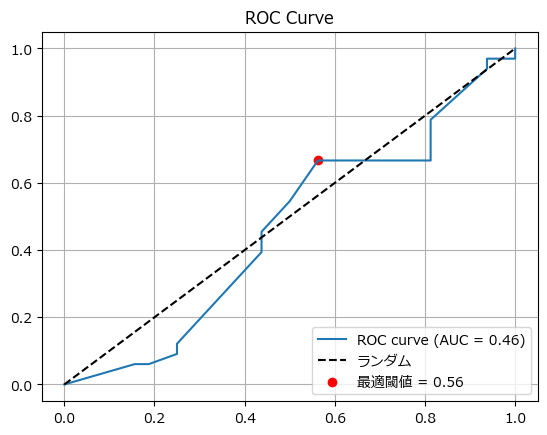

In [56]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ROC曲線とAUCの計算
fpr, tpr, thresholds = roc_curve(y_true_all, y_scores_all)
roc_auc = auc(fpr, tpr)

# YoudenのJ統計量で最適な閾値を求める
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

# 結果表示
print(f"\n===== ROC / AUC による最適閾値評価 =====")
print(f"AUC: {roc_auc:.4f}")
print(f"最適閾値 (Youden J 最大): {best_threshold:.4f}")
#print(f"TPR: {tpr[ix]:.4f}, FPR: {fpr[ix]:.4f}")

matplotlib.rcParams['font.family'] = 'Meiryo'

# ROC曲線のプロット
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='ランダム')
plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', label=f'最適閾値 = {best_threshold:.2f}')
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [58]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# ROC曲線とAUCを計算
fpr, tpr, thresholds = roc_curve(y_true_all, y_scores_all)
roc_auc = auc(fpr, tpr)

# YoudenのJ統計量で最適な閾値を決定
J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print(f"\n===== ROC / AUC による最適閾値の決定 =====")
print(f"AUC: {roc_auc:.4f}")
print(f"最適閾値（Youden J 最大）: {best_threshold:.4f}")

# ---- 再分類 ----
y_pred_thresh = [1 if score >= best_threshold else 0 for score in y_scores_all]

# 混同行列と精度などを表示
print("\n===== 最適閾値による再分類結果 =====")
acc = accuracy_score(y_true_all, y_pred_thresh)
cm = confusion_matrix(y_true_all, y_pred_thresh)

print(f"Accuracy（全体精度）: {acc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)

#print("\nClassification Report:")
#print(classification_report(y_true_all, y_pred_thresh, digits=4))

# ROC曲線描画
#plt.figure()
#plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
#plt.plot([0, 1], [0, 1], 'k--', label='ランダム')
#plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', label=f'最適閾値 = {best_threshold:.2f}')
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('ROC Curve')
#plt.legend(loc='lower right')
#plt.grid(True)
#plt.show()



===== ROC / AUC による最適閾値の決定 =====
AUC: 0.4640
最適閾値（Youden J 最大）: 0.5556

===== 最適閾値による再分類結果 =====
Accuracy（全体精度）: 55.38%
Confusion Matrix:
[[14 18]
 [11 22]]



===== ROC / AUC による最適閾値（左上隅最短距離） =====
AUC: 0.4640
最適閾値（距離最小）: 0.5556
TPR: 0.6667, FPR: 0.5625

===== 最適閾値による再分類結果 =====
Accuracy（全体精度）: 55.38%
Confusion Matrix:
[[14 18]
 [11 22]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5600    0.4375    0.4912        32
           1     0.5500    0.6667    0.6027        33

    accuracy                         0.5538        65
   macro avg     0.5550    0.5521    0.5470        65
weighted avg     0.5549    0.5538    0.5478        65



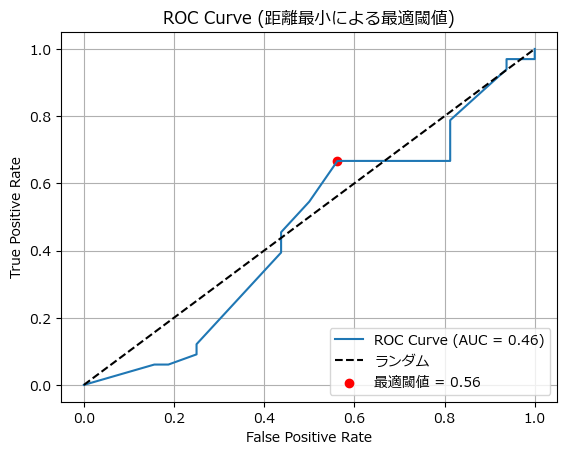

In [59]:
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# ROCとAUCの計算
fpr, tpr, thresholds = roc_curve(y_true_all, y_scores_all)
roc_auc = auc(fpr, tpr)

# 距離を計算（左上隅からの距離）
distances = np.sqrt((1 - tpr)**2 + fpr**2)
ix = np.argmin(distances)
best_threshold = thresholds[ix]

print(f"\n===== ROC / AUC による最適閾値（左上隅最短距離） =====")
print(f"AUC: {roc_auc:.4f}")
print(f"最適閾値（距離最小）: {best_threshold:.4f}")
print(f"TPR: {tpr[ix]:.4f}, FPR: {fpr[ix]:.4f}")

# ---- 再分類 ----
y_pred_thresh = [1 if score >= best_threshold else 0 for score in y_scores_all]

# 混同行列と精度などを表示
print("\n===== 最適閾値による再分類結果 =====")
acc = accuracy_score(y_true_all, y_pred_thresh)
cm = confusion_matrix(y_true_all, y_pred_thresh)

print(f"Accuracy（全体精度）: {acc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_thresh, digits=4))

# ROC曲線描画
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='ランダム')
plt.scatter(fpr[ix], tpr[ix], color='red', label=f'最適閾値 = {best_threshold:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (距離最小による最適閾値)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## 質問1個を１セットとして学習

In [80]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 削除する列を指定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']

# グリッドサーチ用のパラメータ設定
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # 近傍数の候補
    'weights': ['uniform', 'distance'],  # 重みの種類
    'metric': ['manhattan', 'minkowski']  # 距離計量の種類
}

# 全ファイルごとの精度結果を保存するリスト
accuracy_list = []

# 全てのファイルをテストデータとして順番に使うループ
for i in range(len(result_list)):
    print(f"\n===== テストデータ: ファイル {i+1}/{len(result_list)} =====")
    
    # テストデータとして選ぶファイル
    test_file_name, test_df = result_list[i]
    
    # テストデータを前処理
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    # NaNを含む行を削除
    test_df_cleaned = test_df_cleaned.dropna(axis=0)
    
    y_test = test_df_cleaned['Y']
    X_test = test_df_cleaned.drop(columns=['Y'])
    
    # 学習データをリストに格納
    X_train_list = []
    y_train_list = []
    
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i != j:  # テストデータ以外を学習データにする
            train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            # NaNを含む行を削除
            train_df_cleaned = train_df_cleaned.dropna(axis=0)
            train_df_cleaned.reset_index(inplace=True, drop=True)
            
            X_train = train_df_cleaned.drop(columns=['Y'])  # 'label'も削除
            y_train = train_df_cleaned['Y']
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
    
    # 学習データを結合
    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)
    
    # kNNモデルのグリッドサーチ
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    
    # 最適なモデルを取得
    best_model = grid_search.best_estimator_
    print(f"最適パラメータ: {grid_search.best_params_}")
    
    # テストデータで予測
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # クラス1の確率
    
    # 精度計算
    accuracy = accuracy_score(y_test, y_pred) * 100  # 正答率を%に変換
    
    # 精度をリストに保存
    accuracy_list.append((test_file_name, accuracy))
    
    # 結果表示
    print(f"ファイル名: {test_file_name}")
    print(f"予測率: {accuracy:.2f}%")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

# 全ファイルごとの精度を表示
print("\n===== 全ファイルごとの予測率 =====")
for file_name, acc in accuracy_list:
    print(f"ファイル名: {file_name}, 予測率: {acc:.2f}%")

# 予測率が50%以上のものをカウント
count_above_40 = sum(1 for _, acc in accuracy_list if acc >= 40)

# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度40%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_40}ファイルが予測率40%以上")

# 正解ラベルが1のもののうち、予測率が40%以上のものをカウント
count_above_40_for_label_1 = sum(
    1 for (_, acc), (test_file_name, test_df) in zip(accuracy_list, result_list)
    if acc >= 40 and (test_df['Y'] == 1).any()
)

# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率40%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_40_for_label_1}ファイルが予測率40%以上")


===== テストデータ: ファイル 1/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID30.csv
予測率: 60.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 1, 0, 1, 1, 0, 1, 0, 0, 0]
クラス1の確率: [0.2, 0.6, 0.4, 0.8, 1.0, 0.0, 0.6, 0.4, 0.4, 0.4]

===== テストデータ: ファイル 2/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID31.csv
予測率: 60.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 1, 0, 0, 0, 0, 1, 1, 1]
クラス1の確率: [0.0, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333, 0.3333333333333333, 0.0, 0.3333333333333333, 0.6666666666666666, 1.0, 0.6666666666666666]

===== テストデータ: ファイル 3/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID32.csv
予測率: 70.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 0, 1, 1, 1, 1, 0, 1, 0, 1]
クラス1の確率: [0.6666666666666666, 0.0, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.0, 0.66

最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID53.csv
予測率: 40.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 0, 1, 1, 0, 1, 0, 0, 1, 1]
クラス1の確率: [0.6666666666666666, 0.3333333333333333, 1.0, 1.0, 0.3333333333333333, 1.0, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 1.0]

===== テストデータ: ファイル 25/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID54.csv
予測率: 70.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 0, 0, 1, 1, 1, 1, 1, 1, 0]
クラス1の確率: [1.0, 0.0, 0.3333333333333333, 0.6666666666666666, 1.0, 1.0, 0.6666666666666666, 0.6666666666666666, 1.0, 0.3333333333333333]

===== テストデータ: ファイル 26/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID55.csv
予測率: 60.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 0, 0, 1, 0, 0, 0, 1, 1, 0]
クラス1の確率: [1.0, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333

最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID76.csv
予測率: 70.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 1, 1, 0, 0, 0, 1, 1, 1, 1]
クラス1の確率: [1.0, 1.0, 0.6666666666666666, 0.3333333333333333, 0.3333333333333333, 0.0, 0.6666666666666666, 1.0, 0.6666666666666666, 1.0]

===== テストデータ: ファイル 48/65 =====
最適パラメータ: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID77.csv
予測率: 40.00%
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 1, 1, 1, 0, 1, 0, 1, 0, 0]
クラス1の確率: [1.0, 1.0, 1.0, 1.0, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333, 1.0, 0.3333333333333333, 0.3333333333333333]

===== テストデータ: ファイル 49/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID78.csv
予測率: 50.00%
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 0, 0, 1, 0, 0, 1, 1, 1, 1]
クラス1の確率: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 削除する列を指定
columns_to_drop = ['Confidence', 'label', 'AU07', 'AU11', 'AU20']

# グリッドサーチ用のパラメータ設定
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # 近傍数の候補
    'weights': ['uniform', 'distance'],  # 重みの種類
    'metric': ['manhattan', 'minkowski']  # 距離計量の種類
}

# 全ファイルごとの精度結果を保存するリスト
accuracy_list = []

# 全てのファイルをテストデータとして順番に使うループ
for i in range(len(result_list)):
    print(f"\n===== テストデータ: ファイル {i+1}/{len(result_list)} =====")
    
    # テストデータとして選ぶファイル
    test_file_name, test_df = result_list[i]
    
    # テストデータを前処理
    test_df_cleaned = test_df.drop(columns=[col for col in columns_to_drop if col in test_df.columns])
    # NaNを含む行を削除
    test_df_cleaned = test_df_cleaned.dropna(axis=0)
    
    y_test = test_df_cleaned['Y']
    X_test = test_df_cleaned.drop(columns=['Y'])
    
    # 学習データをリストに格納
    X_train_list = []
    y_train_list = []
    
    for j, (train_file_name, train_df) in enumerate(result_list):
        if i != j:  # テストデータ以外を学習データにする
            train_df_cleaned = train_df.drop(columns=[col for col in columns_to_drop if col in train_df.columns])
            # NaNを含む行を削除
            train_df_cleaned = train_df_cleaned.dropna(axis=0)
            train_df_cleaned.reset_index(inplace=True, drop=True)
            
            X_train = train_df_cleaned.drop(columns=['Y'])  # 'label'も削除
            y_train = train_df_cleaned['Y']
            
            X_train_list.append(X_train)
            y_train_list.append(y_train)
    
    # 学習データを結合
    X_train_combined = pd.concat(X_train_list, ignore_index=True)
    y_train_combined = pd.concat(y_train_list, ignore_index=True)
    
    # kNNモデルのグリッドサーチ
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
    grid_search.fit(X_train_combined, y_train_combined)
    
    # 最適なモデルを取得
    best_model = grid_search.best_estimator_
    print(f"最適パラメータ: {grid_search.best_params_}")
    
    # テストデータで予測
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # クラス1の確率
    
    # 精度計算（参考用）
    accuracy = accuracy_score(y_test, y_pred)

    # クラス1の予測割合を計算
    positive_ratio = (y_pred == 1).mean()

    # クラス1割合をリストに保存（リスト名をわかりやすく変更してもOK）
    accuracy_list.append((test_file_name, positive_ratio))
    
    # 結果表示
    print(f"ファイル名: {test_file_name}")
    print(f"予測確率: {positive_ratio:.2f}")
    print(f"正解ラベル: {y_test.tolist()}")
    print(f"予測ラベル: {y_pred.tolist()}")
    print(f"クラス1の確率: {y_pred_prob.tolist()}")

print("\n===== 全ファイルごとのクラス1予測割合 =====")
for file_name, ratio in accuracy_list:
    print(f"ファイル名: {file_name}, クラス1割合: {ratio:.2f}")


# クラス1割合が40%以上のものをカウント
count_above_40 = sum(1 for _, ratio in accuracy_list if ratio >= 0.4)


# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度40%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_40}ファイルが予測率40%以上")

count_above_40_for_label_1 = sum(
    1 for (_, ratio), (_, test_df) in zip(accuracy_list, result_list)
    if ratio >= 0.4 and (test_df['Y'] == 1).any()
)


# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率40%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_40_for_label_1}ファイルが予測率40%以上")


===== テストデータ: ファイル 1/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID30.csv
予測確率: 0.10
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
クラス1の確率: [0.2, 0.2, 0.0, 0.8, 0.2, 0.4, 0.4, 0.0, 0.0, 0.0]

===== テストデータ: ファイル 2/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID31.csv
予測確率: 0.30
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 1, 0, 0, 0, 0, 1]
クラス1の確率: [0.2, 0.4, 0.4, 0.6, 0.6, 0.2, 0.4, 0.2, 0.0, 1.0]

===== テストデータ: ファイル 3/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID32.csv
予測確率: 0.10
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
クラス1の確率: [0.2, 0.0, 0.2, 0.6, 0.0, 0.2, 0.0, 0.4, 0.0, 0.4]

===== テストデータ: ファイル 4/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID33.csv
予測確率: 0.30
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 

最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID59.csv
予測確率: 0.70
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 1, 1, 1, 0, 0, 0, 1, 1, 1]
クラス1の確率: [1.0, 0.8, 0.8, 1.0, 0.2, 0.4, 0.2, 0.6, 1.0, 0.6]

===== テストデータ: ファイル 31/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
ファイル名: filtered_ID60.csv
予測確率: 0.30
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [0, 0, 0, 1, 0, 0, 1, 1, 0, 0]
クラス1の確率: [0.3333333333333333, 0.0, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 0.6666666666666666, 0.3333333333333333, 0.0]

===== テストデータ: ファイル 32/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID61.csv
予測確率: 0.50
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 1, 0, 1, 0, 0, 0, 1, 1, 0]
クラス1の確率: [0.8, 1.0, 0.4, 0.8, 0.2, 0.2, 0.2, 0.8, 0.6, 0.4]

===== テストデータ: ファイル 33/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5

最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID86.csv
予測確率: 0.90
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
クラス1の確率: [1.0, 1.0, 0.6, 0.6, 1.0, 1.0, 0.4, 1.0, 0.8, 0.8]

===== テストデータ: ファイル 58/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID87.csv
予測確率: 0.30
正解ラベル: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測ラベル: [0, 0, 1, 1, 0, 0, 0, 0, 1, 0]
クラス1の確率: [0.2, 0.2, 0.6, 0.6, 0.2, 0.4, 0.4, 0.4, 0.6, 0.2]

===== テストデータ: ファイル 59/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID88.csv
予測確率: 0.20
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
クラス1の確率: [0.8, 0.0, 0.4, 0.4, 0.0, 0.2, 0.4, 0.4, 0.6, 0.4]

===== テストデータ: ファイル 60/65 =====
最適パラメータ: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
ファイル名: filtered_ID89.csv
予測確率: 0.70
正解ラベル: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測ラベル: [1, 0, 0, 1, 1,

In [62]:
# 予測率が50%以上のものをカウント
count_above_50 = sum(1 for _, acc in accuracy_list if acc >= 50)

# 結果を表示
total_files = len(accuracy_list)
print(f"\n===== 精度50%以上のファイル数 =====")
print(f"{total_files}ファイル中 {count_above_50}ファイルが予測率50%以上")

# 正解ラベルが1のもののうち、予測率が50%以上のものをカウント
count_above_50_for_label_1 = sum(
    1 for (_, acc), (test_file_name, test_df) in zip(accuracy_list, result_list)
    if acc >= 50 and (test_df['Y'] == 1).any()
)

# 結果を表示
print(f"\n===== 正解ラベルが1のもののうち予測率50%以上のファイル数 =====")
print(f"正解ラベルが1のファイル中 {count_above_50_for_label_1}ファイルが予測率50%以上")


===== 精度50%以上のファイル数 =====
65ファイル中 42ファイルが予測率50%以上

===== 正解ラベルが1のもののうち予測率50%以上のファイル数 =====
正解ラベルが1のファイル中 26ファイルが予測率50%以上


AUC: 0.5227
最適閾値（左上隅最短距離）: 0.7333


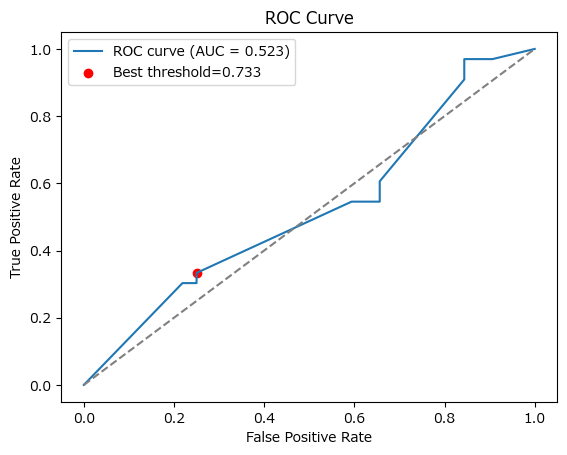

In [81]:
from sklearn.metrics import roc_curve, auc

# y_true_all: 各ファイルの正解ラベル（0/1）
# y_score_all: 各ファイルのクラス1確率（float）

# 例）ループ中にy_true_all.append(y_test.iloc[0]), y_score_all.append(y_pred_prob[0])をしておく

fpr, tpr, thresholds = roc_curve(y_true_all, y_score_all)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

# YoudenのJ統計量ではなく「左上隅からの距離」で最適閾値を探す例
import numpy as np

# 左上隅(0,1)からの距離を計算
distances = np.sqrt(fpr**2 + (1 - tpr)**2)
best_index = np.argmin(distances)
best_threshold = thresholds[best_index]

print(f"最適閾値（左上隅最短距離）: {best_threshold:.4f}")

# ROC曲線のプロット（任意）
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.scatter(fpr[best_index], tpr[best_index], color='red', label=f'Best threshold={best_threshold:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
